In [20]:
import pandas as pd
import numpy as np
import os

os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"


from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="1"

numpyro.enable_x64()

In [21]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [22]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)

num_stars = 100

In [23]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

hierarchical_params = ['mu_zini', 'std_zini', 'mu_alphaMLT', 'std_alphaMLT', 'mu_age', 'std_age']

df = df_full[inputs+outputs+['logLPhot']]

normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at al

seed = 42

df_train = df.sample(frac=0.95, random_state=seed)

df_test = df.drop(df_train.index)

hare_idx = 1070114

massini = df_test.loc[hare_idx, 'massini']

zini = df_test.loc[hare_idx, 'zini']

yini = df_test.loc[hare_idx, 'yini']

alphaMLT = df_test.loc[hare_idx, 'alphaMLT']

eta = df_test.loc[hare_idx, 'eta']

alphaFe = df_test.loc[hare_idx, 'alphaFe']

age = df_test.loc[hare_idx, 'age']

track_indices = df_test.loc[1069728:1070650].index

df_small = df.sample(frac = 0.001, random_state = seed)

In [24]:
prior_values = [massini, zini, yini, alphaMLT, age, eta, alphaFe]

prior_widths = [0.1, 1.5, 0.1, 0.1, 3000, 0.1, 0.03] 

priors = [(prior_values[i], prior_widths[i]) for i in range(len(prior_values))]

cluster_consts = {}

for key, value in zip(model_outputs.inputs, priors):
    if key not in cluster_consts:
        cluster_consts[key] = value
    else:
        cluster_consts[key].append(value)
cluster_consts

{'massini': (np.float64(0.834), 0.1),
 'zini': (np.float64(0.0009642060000000507), 1.5),
 'yini': (np.float64(0.246469727), 0.1),
 'alphaMLT': (np.float64(2.11914062), 0.1),
 'age': (np.float64(12097.8986), 3000),
 'eta': (np.float64(0.269677734), 0.1),
 'alphaFe': (np.float64(0.0), 0.03)}

In [25]:
fake_obs = {'FeH':df_test.loc[hare_idx, 'FeH'], 'LPhot':df_test.loc[hare_idx, 'LPhot'], 'Teff':df_test.loc[hare_idx, 'Teff'], 'numax':3090*df_test.loc[hare_idx, 'numax'], 'dnuSer':135*df_test.loc[hare_idx, 'dnuSer'], 'logLPhot':df_test.loc[hare_idx, 'logLPhot']}

# Make a fake cluster

In [26]:
def fake_stars(uncs, consts = cluster_consts, obs = model_outputs.obs_dict):

    with numpyro.plate("star", 1):

        age = numpyro.sample('age', dist.Normal(consts['age'][0], consts['age'][1]))

        tau = sample_beta('tau', 1, 0.1, alpha = 10, beta = 10)

        massini = numpyro.deterministic ('massini', (0.6426*10**4/age)**(1/3.2))

        zini = numpyro.sample('zini', dist.LogNormal(np.log(consts['zini'][0]), consts['zini'][1]))

        yini = numpyro.sample('yini', dist.LogNormal(np.log(consts['yini'][0]), consts['yini'][1]))

        alphaMLT = numpyro.sample('alphaMLT', dist.TruncatedNormal(consts['alphaMLT'][0],consts['alphaMLT'][1], low = 1.5, high = 2.3))

        eta = numpyro.sample('eta', dist.TruncatedNormal(consts['eta'][0], consts['eta'][1], low = 0, high = 0.3))

        alphaFe = numpyro.sample('alphaFe', dist.Normal(consts['alphaFe'][0], consts['alphaFe'][1]))
               
        params = jnp.stack([massini, zini, yini, alphaMLT, age, eta, alphaFe], axis = -1)

        pred = model_outputs(params)



    FeH = numpyro.sample("FeH", dist.Normal(pred[:, 0], uncs['FeH']), obs=obs['FeH'])
    
    logLPhot = numpyro.sample("logLPhot", dist.LogNormal(jnp.log(pred[:, 1]), uncs['logLPhot']), obs=obs['logLPhot'])

    Teff = numpyro.sample("Teff", dist.Normal(pred[:, 2], uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.Normal(pred[:, 3]*3090, uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.Normal(pred[:, 4]*135, uncs['dnuSer']), obs=obs['dnuSer'])
 





In [27]:
num_warmup, num_samples = 1000, 1000

num_chains = 1

sampler = NUTS(fake_stars, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_median) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [28]:
phys_unc = {'Teff':150, 'numax': 0.1*fake_obs['numax'], 'dnuSer':0.1*fake_obs['dnuSer'], 'FeH':0.1, 'logLPhot':0.05}
#Large errors on numax and dnu reflective of std on residuals from the network

In [29]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(fake_stars, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=phys_unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data

Inference data with groups:
	> prior

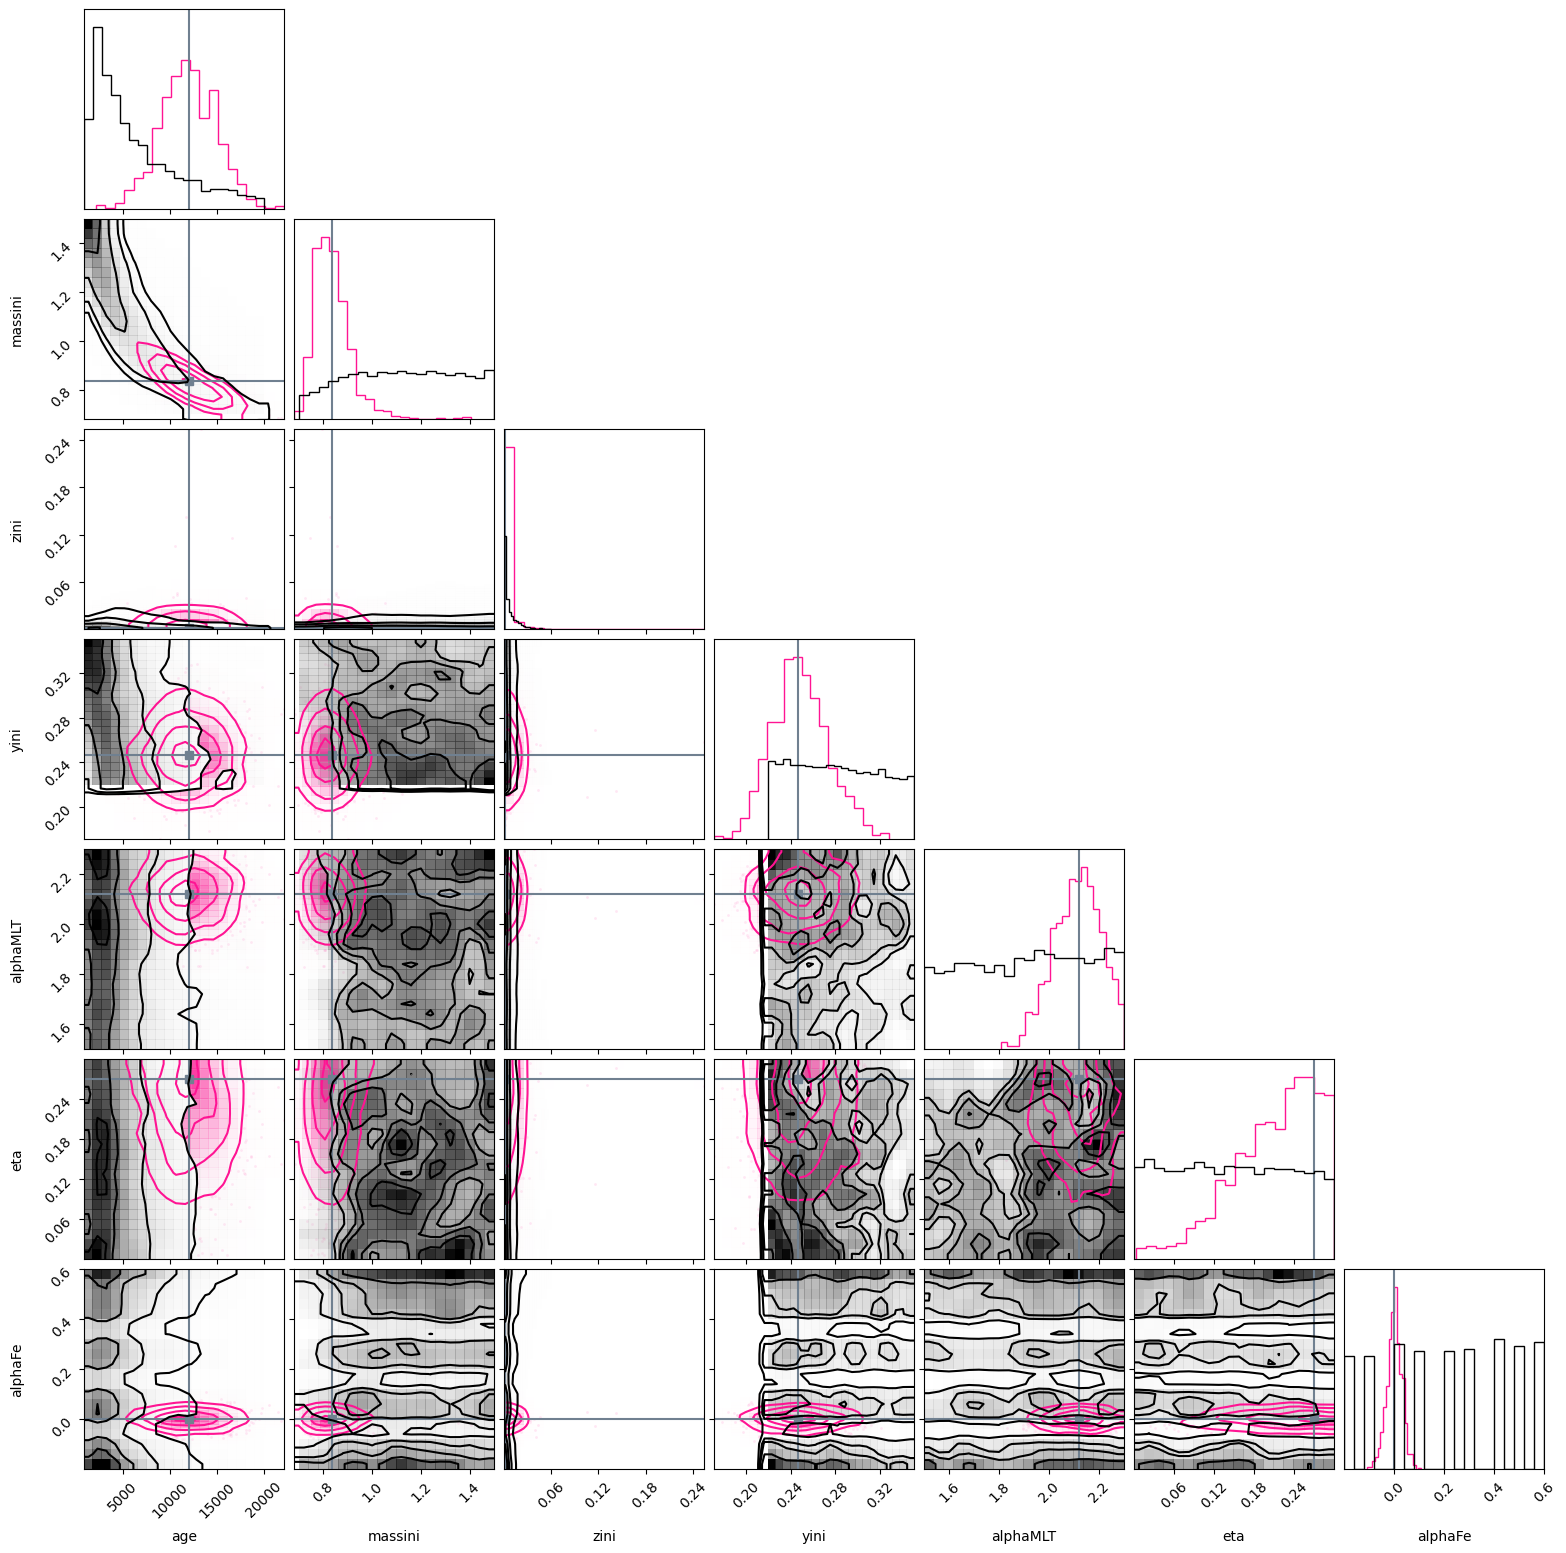

In [30]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', smooth = True, plot_datapoints = True, truths = [cluster_consts[i][0] for i in ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']], truth_color = 'slategrey', weights = np.ones(num_prior_samples)/(num_prior_samples), zorder = 100)
corner.corner(df_small[['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']],zorder = 0, alpha = 0.1, fig = fig, smooth = True, weights = np.ones_like(df_small['massini'])/len(df_small), plot_datapoints = False,)
plt.show()

In [31]:
fake_obs

{'FeH': np.float64(-1.141214203525742),
 'LPhot': np.float64(50.81158881955278),
 'Teff': np.float64(5177.965784),
 'numax': np.float64(34.273789384394775),
 'dnuSer': np.float64(4.509570052091168),
 'logLPhot': np.float64(1.7059627750082371)}

In [32]:
mcmc.run(jax.random.PRNGKey(0),  uncs=phys_unc, obs=fake_obs)

mcmc.print_summary()

sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [17:14<00:00,  1.93it/s, 1023 steps of size 4.88e-03. acc. prob=0.92]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
     age[0]  11575.82   2542.32  11651.07   6900.87  15258.47     34.09      1.00
 alphaFe[0]      0.00      0.03      0.00     -0.05      0.05    689.51      1.00
alphaMLT[0]      2.09      0.09      2.09      1.95      2.22    523.93      1.00
     eta[0]      0.21      0.06      0.22      0.12      0.29    391.61      1.00
tau_beta[0]      0.51      0.11      0.51      0.32      0.66    715.73      1.00
    yini[0]      0.26      0.01      0.26      0.24      0.26     52.09      1.00
    zini[0]      0.00      0.00      0.00      0.00      0.00    371.67      1.00

Number of divergences: 0


In [35]:
0.2485+cluster_consts['zini'][0], cluster_consts['yini']

(np.float64(0.24946420600000005), (np.float64(0.246469727), 0.1))

In [316]:
posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

posterior_predictive = Predictive(fake_stars, posterior_samples=posterior, parallel=True, batch_ndims=2)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)

In [317]:
params = jnp.stack([posterior['massini'][0].T, posterior['zini'][0].T, posterior['yini'][0].T, posterior['alphaMLT'][0].T, posterior['age'][0].T, posterior['eta'][0].T, posterior['alphaFe'][0].T], axis = -1)

pred = model_outputs(params)


In [318]:
cluster_consts

{'massini': (np.float64(0.834), 0.1),
 'zini': (np.float64(0.0009642060000000507), 1.5),
 'yini': (np.float64(0.246469727), 0.1),
 'alphaMLT': (np.float64(2.11914062), 0.1),
 'age': (np.float64(12097.8986), 3000),
 'eta': (np.float64(0.269677734), 0.1),
 'alphaFe': (np.float64(0.0), 0.03)}

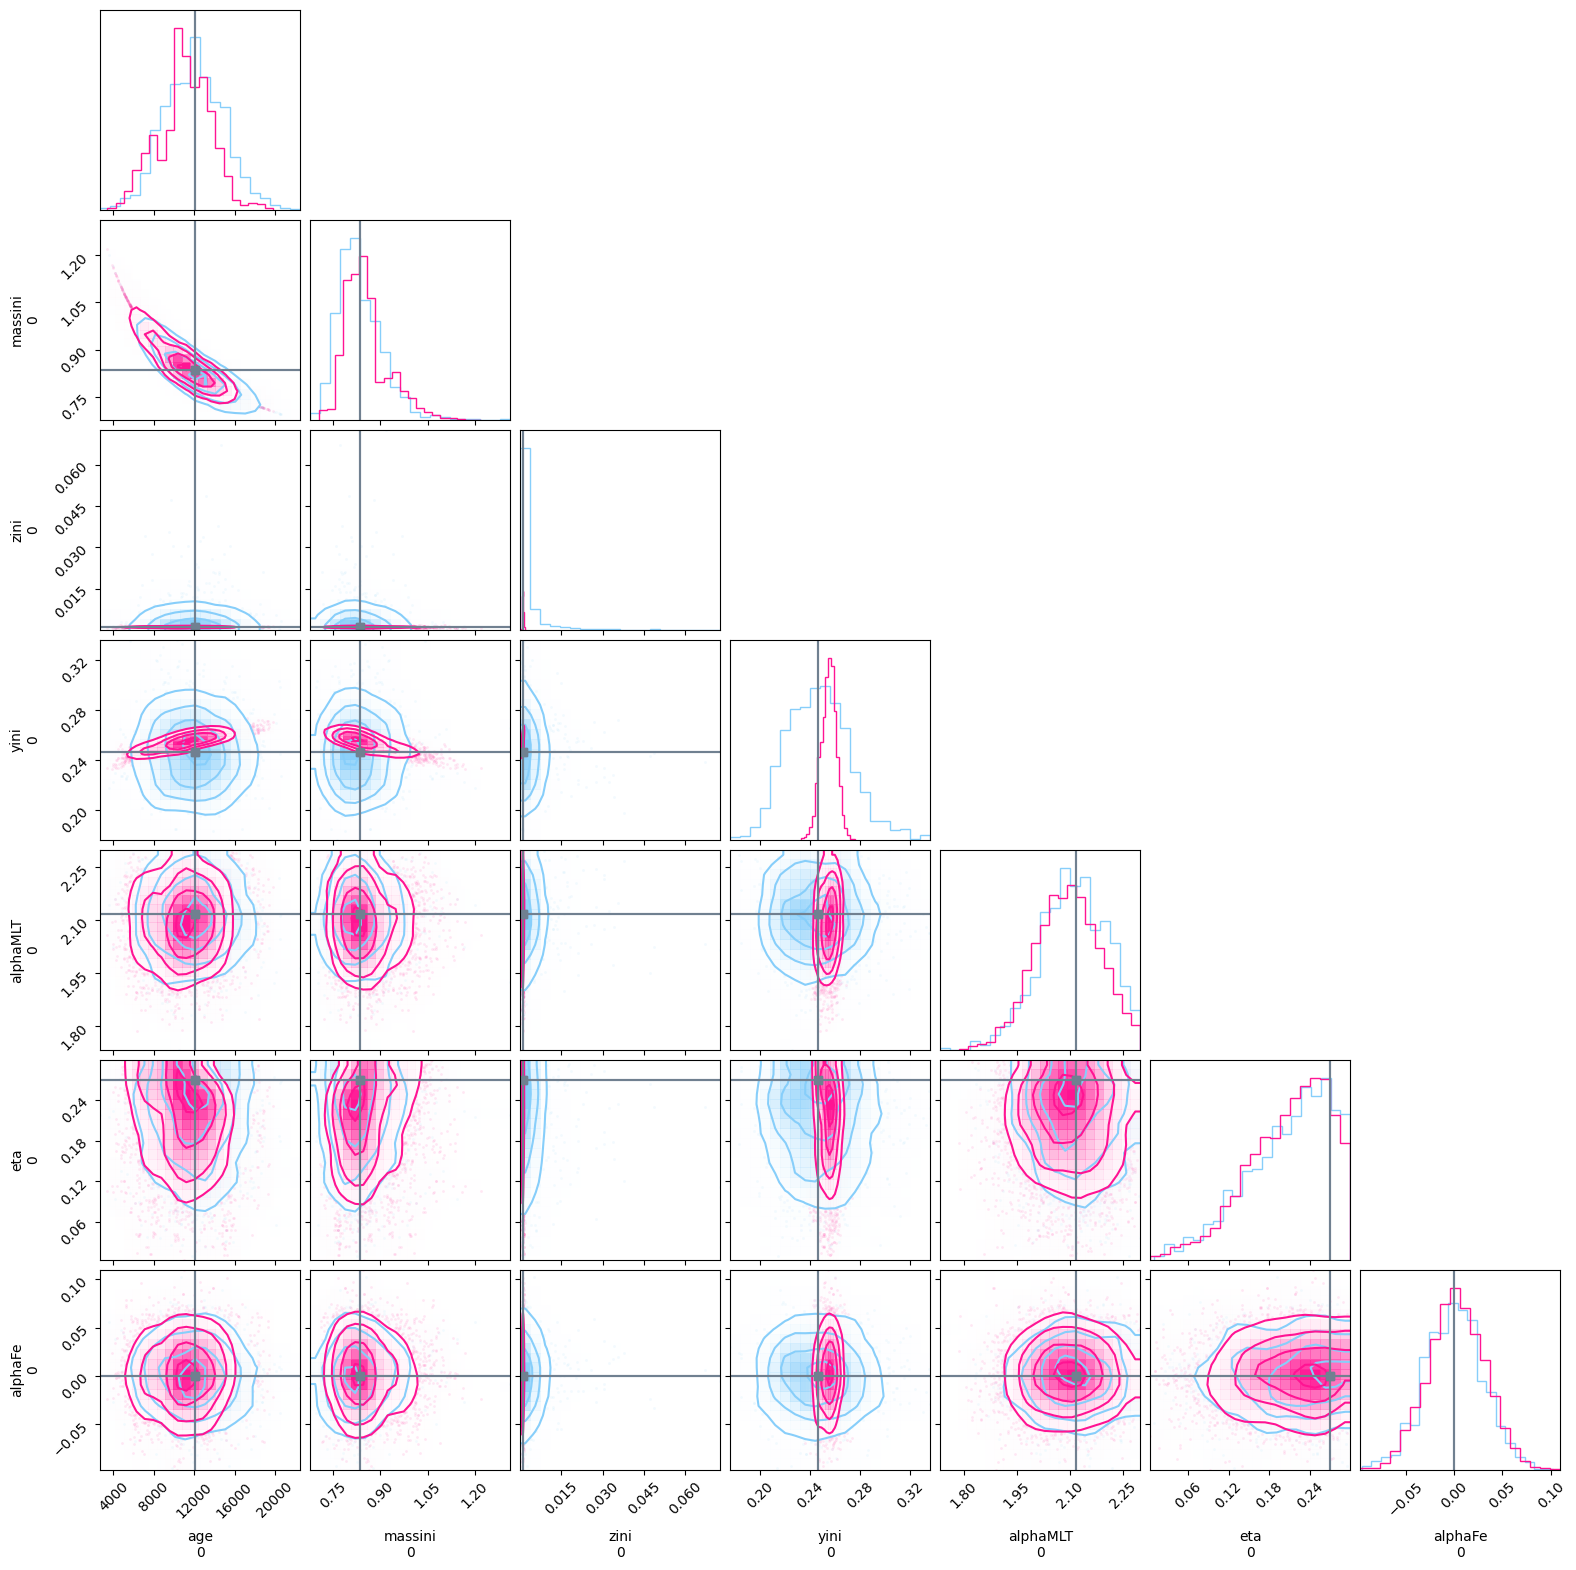

In [319]:

fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'lightskyblue', smooth = True, plot_datapoints = True, truths = [cluster_consts[i][0] for i in ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']], truth_color = 'slategrey', weights = np.ones(num_prior_samples)/(num_prior_samples), )
corner.corner(data, group="posterior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', zorder = 1,smooth = True, plot_datapoints = True, truths = [cluster_consts[i][0] for i in ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']], truth_color = 'slategrey', weights = np.ones(num_chains*num_samples)/(num_chains*num_samples),fig = fig)
fig.savefig(f'./corner-hare-idx-{hare_idx}-massfromage-zini-{prior_widths[1]}-yini-{prior_widths[2]}-alphaMLT-{prior_widths[3]}-age-{prior_widths[4]}-eta-{prior_widths[5]}-alphaFe-{prior_widths[6]}.png', bbox_inches = 'tight', dpi = 150)
plt.show()


In [320]:
cluster_df = pd.DataFrame(columns = model_outputs.outputs)

cluster_df['FeH'] = pred[0].T[0]

cluster_df['logLPhot'] = pred[0].T[1]

cluster_df['Teff'] = pred[0].T[2]

cluster_df['numax'] = pred[0].T[3]*3090

cluster_df['dnuSer'] = pred[0].T[4]*135

draws = cluster_df.sample(1000)



Text(0, 0.5, 'log(L/L$_{\\odot}$)')

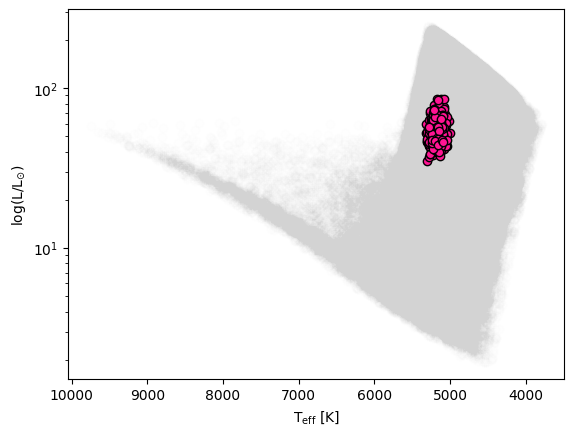

In [321]:
plt.scatter(df_test['Teff'], 10**df_test['logLPhot'], color = 'lightgrey', alpha = 0.01)
plt.scatter(draws['Teff'], 10**draws['logLPhot'], facecolor = 'deeppink', edgecolor = 'black')
plt.gca().invert_xaxis()
plt.semilogy()
plt.xlabel(r'T$_{\mathrm{eff}}$ [K]')
plt.ylabel(r'log(L/L$_{\odot}$)')


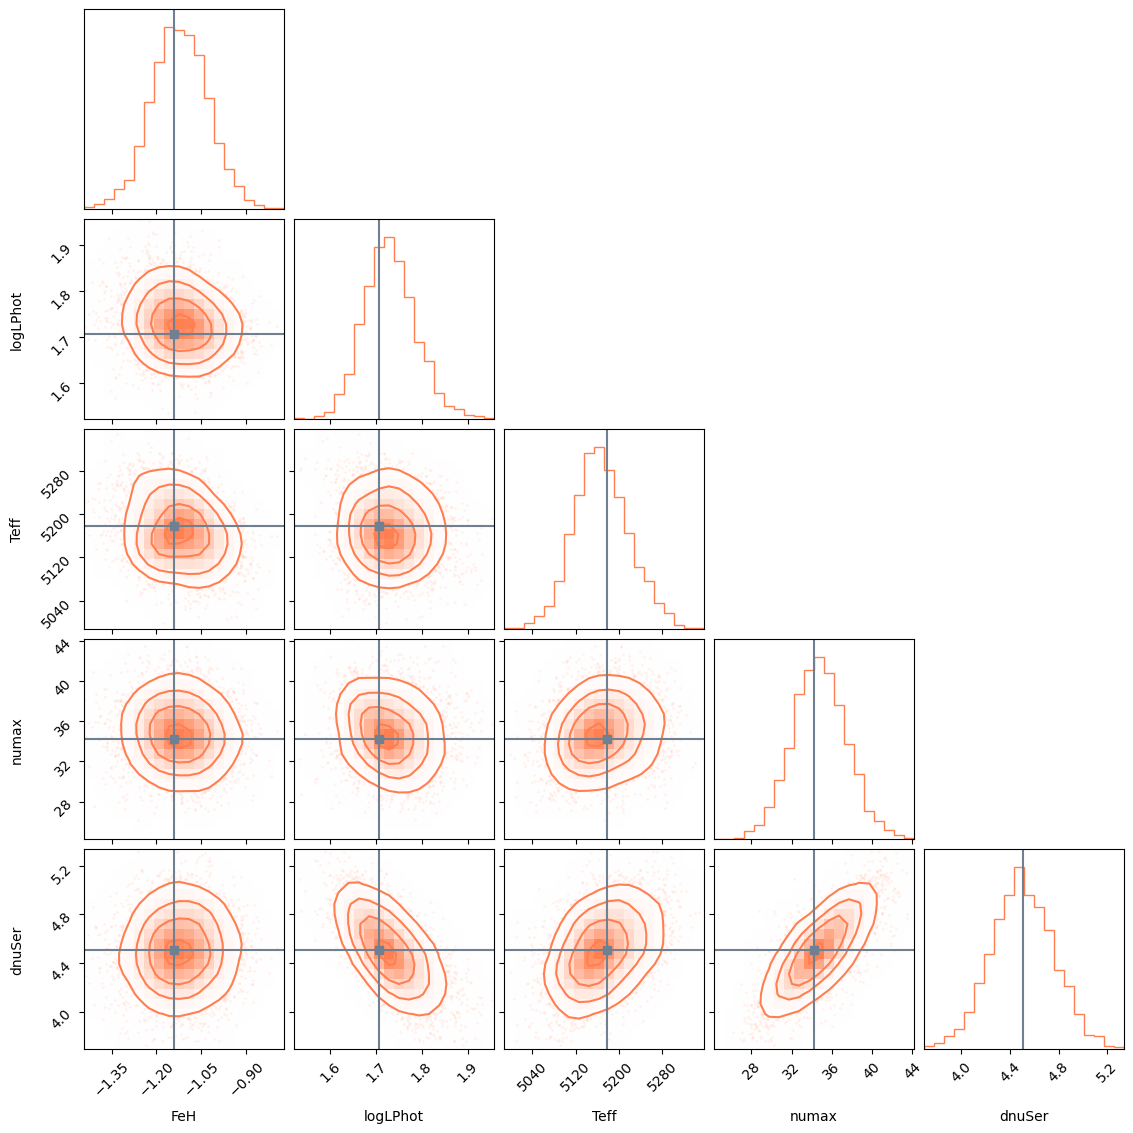

In [322]:
fig = corner.corner(cluster_df[model_outputs.outputs], smooth = True, color = 'coral', truths = [fake_obs[i] for i in model_outputs.outputs], truth_color = 'slategrey')
plt.show()